### Calcuating Boltzmann Constant from Johnson Noise Varying Frequency Bandwidth

In this section of the experiment, we change the frequency bandwidth of the High-Level Electronics. To find the uncertainties in our measurements, we look at the data sheets for our handheld multimeter, which is used to calculate the resistance of our resistor, our multimeter, which is used to calculate Johnson Noise squared, and two thermometers, measuring the temperature of the room.

Here are the datasheets we look at for error propogation:

https://www.dropbox.com/scl/fi/1vq24o1unn4n0ikm1oeed/ZT111-Eng.pdf?rlkey=g51p6y0agtyp7edrfm9i7kx83&e=1&dl=0
https://www.manualslib.com/manual/1522469/Zotek-Zt111.html
https://www.manualslib.com/manual/2894668/Protek-B8000fd-Series.html?page=2#manual
https://www.manualslib.com/manual/2894668/Protek-B8000fd-Series.html?page=2#manual
https://res.cloudinary.com/iwh/image/upload/q_auto,g_center/assets/1/26/Documents/Protek/protekb8040fd_datasheet.pdf

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
import pandas as pd

In [2]:
# Data input
df = pd.read_csv("/Users/jacobbalek/Documents/The Ohio State University/PHYS 5700 Adv Physics Lab/PHYS 5700 Adv Physics Lab Spring 2026/Johnson Noise/Johnson_Noise_Data_Frequency.csv")
print("Length of full df: ", len(df)) #Expect 6 * 15 = 90
print(df.head(), "\n")

# Remove NaN cols (clean)
df_clean = df.dropna()
print("Length of Cleaned df: ", len(df_clean), "\n")

print("Columns in df: ")
for col in df_clean:
    print(col)

Length of full df:  78
  Resistor R1 = 100k Ohms  High-pass Filter f1 (Hz)  Low-pass Filter f2 (kHz)  \
0                    100k                      10.0                       3.3   
1                    100k                       NaN                       NaN   
2                    100k                       NaN                       NaN   
3                    100k                       NaN                       NaN   
4                    100k                       NaN                       NaN   

   delta f  G2 Gain  <Vsq> read (V)  Mean <Vsq> Read (V)  STD <Vsq> Read (V)  
0   3654.0   2000.0          0.8920             0.899617            0.005038  
1      NaN      NaN          0.9044                  NaN                 NaN  
2      NaN      NaN          0.9016                  NaN                 NaN  
3      NaN      NaN          0.8947                  NaN                 NaN  
4      NaN      NaN          0.9017                  NaN                 NaN   

Length of Clea

In [3]:
# Plot values from "Mean <Vsq> Read (V)"
voltage = df_clean["Mean <Vsq> Read (V)"]
gain = df_clean["G2 Gain"]
delta_f = df_clean["delta f"]
std = df_clean["STD <Vsq> Read (V)"]

In [4]:
# <Vsq (t)> = {G1 G2}^2 / 10V <VJ^2 + VN^2>
# <VJ^2 + VN^2> = <Vsq (t)> * 10 V / {G1 G2}^2

def infer_noise(volts, G2, G1 = 600):
    return volts * 10 / ((G1 * G2)**2)

noise_tot = infer_noise(voltage, gain)
noise_tot_log = np.log10(noise_tot)

d_f_log = np.log10(delta_f)

In [5]:
def johnson_noise_uncerts(v_read_uncert, G2, G1 = 600):
    return v_read_uncert * 10 / ((G1 * G2)**2)

def freq_uncerts(freq):
    return freq * 0.04

johnson_noise_uncerts_vals = []
for i in range(len(std)):
    johnson_noise_uncerts_vals.append(johnson_noise_uncerts(std.iloc[i], gain.iloc[i]))

delta_f_uncerts = []
for i in range(len(delta_f)):
    delta_f_uncerts.append(freq_uncerts(delta_f.iloc[i]))

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7578/3339837850.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel(f'$\Delta f$ (Hz)')
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7578/3339837850.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


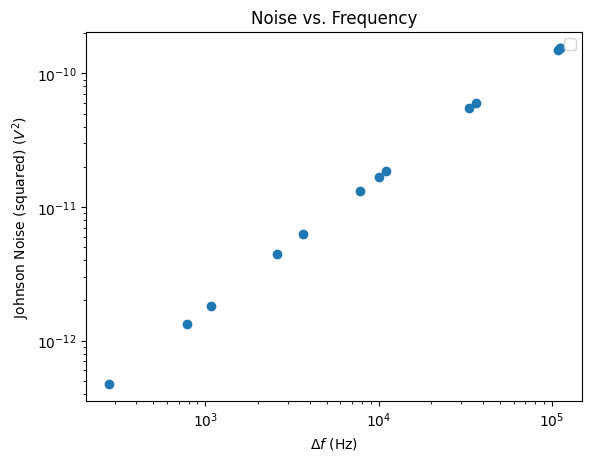

In [6]:
# Plot Data
plt.scatter(delta_f, noise_tot)
plt.xscale('log')
plt.yscale('log')
# plt.yrange(5,-5)
plt.xlabel(f'$\Delta f$ (Hz)')
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel(f'Johnson Noise (squared) ($V^2$)')
plt.title('Noise vs. Frequency')
plt.legend()
# plt.savefig('TimeDelay_vs_CableLength_ODRFit.png', dpi=300)
plt.show()

In [7]:
# Fit to line
# Plot using ODR
def linear_func(B, x):
    return B[0] * x + B[1]
linear = odr.Model(linear_func)

mydata = odr.RealData(delta_f, noise_tot, delta_f_uncerts, johnson_noise_uncerts_vals)

sol = odr.ODR(mydata, linear, beta0=[9., 1.])
myoutput = sol.run()
myoutput.pprint()

Beta: [1.60545228e-15 3.98492923e-14]
Beta Std Error: [4.21150250e-17 3.91454228e-14]
Beta Covariance: [[ 4.24079741e-34 -1.85761513e-31]
 [-1.85761513e-31  3.66383053e-28]]
Residual Variance: 4.182409962653706
Inverse Condition #: 0.000949318582591526
Reason(s) for Halting:
  Sum of squares convergence


In [8]:
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square

print("Chi squared: ", chi_sq)
print("Reduced Chi squared: ", red_chi_sq)

Chi squared:  46.006509589190756
Reduced Chi squared:  4.182409962653706


<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\D'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7578/3909230835.py:26: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2$: {chi_sq:.3f}\n"
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7578/3909230835.py:27: SyntaxWarning: invalid escape sequence '\c'
  f"Reduced $\chi^2$: {red_chi_sq:.3f}"
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7578/3909230835.py:34: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel(f'$\Delta f$ (Hz)')


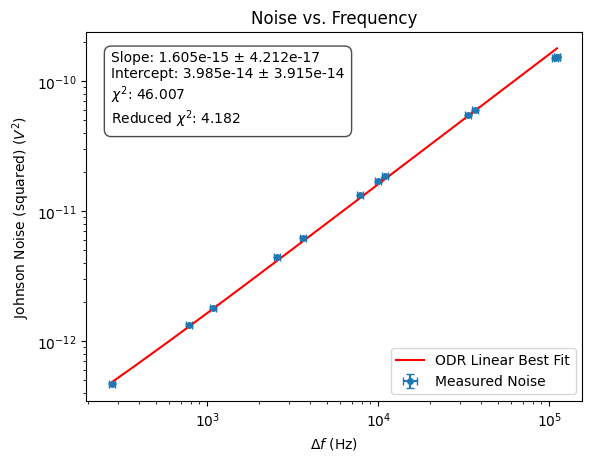

In [16]:
# Plot with best fit line
# Make a plot of time delay verus cable length

# Plot data
# plt.scatter(delta_f, noise_tot)
plt.errorbar(delta_f, noise_tot, 
             xerr=delta_f_uncerts, 
             yerr=johnson_noise_uncerts_vals, # Divide by sqrt(6)
             fmt='o', label='Measured Noise', capsize=3, markersize=4)


# Plot best fit line
x_fit = np.linspace(min(delta_f), max(delta_f), 1000)
y_fit = linear_func(myoutput.beta, x_fit)
plt.plot(x_fit, y_fit, color='red', label='ODR Linear Best Fit')

slope = myoutput.beta[0]
slope_err = myoutput.sd_beta[0]
intercept = myoutput.beta[1]
intercept_err = myoutput.sd_beta[1]
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square
stats_text = (
    f"Slope: {slope:.3e} ± {slope_err:.3e}\n"
    f"Intercept: {intercept:.3e} ± {intercept_err:.3e}\n"
    f"$\chi^2$: {chi_sq:.3f}\n"
    f"Reduced $\chi^2$: {red_chi_sq:.3f}"
)

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

plt.xlabel(f'$\Delta f$ (Hz)')
plt.xscale('log')
plt.yscale('log')
# plt.ylim(0,0.2E-10)
# plt.xlim(0,2E4)
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel(f'Johnson Noise (squared) ($V^2$)')
plt.title('Noise vs. Frequency')
plt.legend()
plt.savefig('noise_vs_bandwidth_plot.png', dpi=300)
plt.show()

Note that we don't have to adjust our noise since we chose a region where the Amplifier chip noise is negligible compared to Johnson noise.

## Calculate Boltsmann Constant

Recall Johnson Noise Squared = 4 kb T R delta f

kb = Vj^2 / (4 * T * R * delta f); our slope is Vj^2 /delta_f, so multiply slope / (4 * T * R)

Recal Boltzmann constant is ~ 1.380649 × 10-23

In [10]:
R = 995e2 # 100k Ohms
T = 294.817 # ~ 71 degrees F; Adjust in future
print("Slope: ", slope)
print("Calculated Boltzmann constant: ", slope / ((4 * T * R)))

Slope:  1.605452276143853e-15
Calculated Boltzmann constant:  1.368238496695798e-23


In [11]:
print("Average Johnson Noise value: ", sum(noise_tot) / len(noise_tot))
print("Average uncertainty in measured Johnson Noise squared: ", sum(johnson_noise_uncerts_vals) / len(johnson_noise_uncerts_vals))
print("Average uncertainty in delta f: ", sum(delta_f_uncerts) / len(delta_f_uncerts))

print("Average delta f: ", sum(delta_f) / len(delta_f))
print("Average uncertainty in delta f: ", sum(delta_f_uncerts) / len(delta_f_uncerts))

max_uncert_delta_f = max(delta_f_uncerts)
max_delta_f = max(delta_f)

# print(max_uncert_delta_f / (max_delta_f**2))
1 / (sum(delta_f_uncerts) / len(delta_f_uncerts));

Average Johnson Noise value:  4.889668383161206e-11
Average uncertainty in measured Johnson Noise squared:  1.0735453809057456e-13
Average uncertainty in delta f:  1344.329230769231
Average delta f:  33608.230769230766
Average uncertainty in delta f:  1344.329230769231


In [12]:
temp_uncert = 0.785674201
R_uncert = R * 0.005 + 30
print("Resistor val and uncert: ", R, R_uncert)

Resistor val and uncert:  99500.0 527.5


In [13]:
slope_uncert_part = (1 / (4 * T * R)**2 * slope_err**2)
temp_uncert_part = ((slope / (4 * T**2 * R))**2 * temp_uncert**2)
R_uncert_part = ((slope / (4 * T * R**2))**2 * R_uncert**2)
# R_uncert_part = 0

print("Error contribution from slope: ", slope_uncert_part)
print("Error contribution from T: ", temp_uncert_part)
print("Error contribution from R: ", R_uncert_part)

tot_uncert =  np.sqrt(slope_uncert_part + temp_uncert_part + R_uncert_part)
print("Total uncertainty in Boltzmann constant calculation: ", tot_uncert)

Error contribution from slope:  1.2882582628116289e-49
Error contribution from T:  1.3295465610624952e-51
Error contribution from R:  5.261655109034963e-51
Total uncertainty in Boltzmann constant calculation:  3.6799052698576404e-25


In [14]:
kB = 1.380649e-23
print("Difference between measured and expected: ", kB - slope / ((4 * T * R)))

Difference between measured and expected:  1.2410503304202047e-25


This is within our uncertainty!